15.8 (CLASSIFICATION WITH THE IRIS DATASET: HYPERPARAMETER TUNING) Using scikit-learn’s KFold class and cross_val_score function, determine the optimal k value for classifying Iris samples using a KNeighborsClassifier.

Imports

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

Load Dataset

In [4]:
iris = load_iris()
X, y = iris.data, iris.target

Tuning with cross_val as assigned

In [6]:
k_range = range( 1,31 )
k_scores = {}

for k in k_range:
  knn = KNeighborsClassifier( n_neighbors = k )
  scores = cross_val_score( knn, X, y, cv = 10 )
  k_scores[k] = scores.mean()

Find optimal k value

In [30]:
optimal_k = max( k_scores, key = k_scores.get )
best_score = k_scores[ optimal_k ]

Display results

In [31]:
print( "Optimal k value: ", optimal_k)

Optimal k value:  13


Put results in a DataFrame

In [9]:
df = pd.DataFrame( list( k_scores.items() ), columns = ["k", "Accuracy"])

Full Graph

<Figure size 800x500 with 0 Axes>

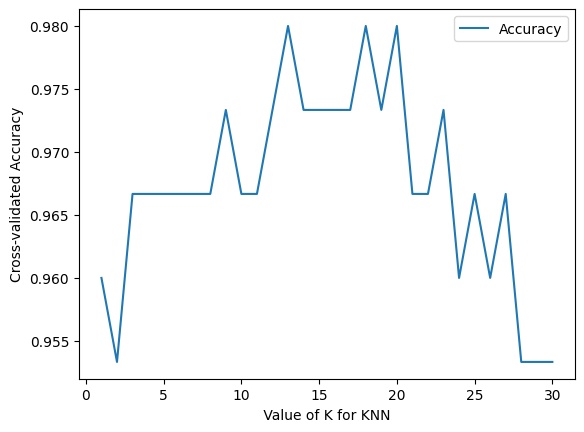

In [19]:
plt.figure( figsize = (8, 5) )
ax1 = df.plot(
    x = "k",
    y = "Accuracy",
)

ax1.set_xlabel( " Value of K for KNN " )
ax1.set_ylabel( "Cross-validated Accuracy" )
plt.show()

Cropped graph

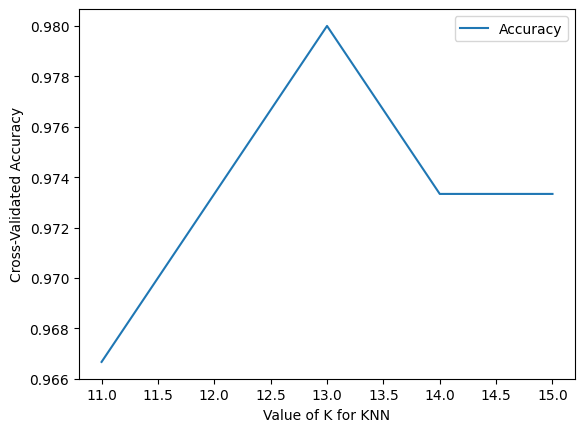

In [23]:
df_cropped = df[ ( df[ "k" ] >= 11 ) & ( df[ "k" ] <= 15 ) ]

ax2 = df_cropped.plot(
    x="k",
    y="Accuracy",
)
ax2.set_xlabel("Value of K for KNN")
ax2.set_ylabel("Cross-Validated Accuracy")
plt.show()

Run GridSearchCV

In [28]:
param_grid = { "n_neighbors": list( range( 1, 31) ) }
grid = GridSearchCV( KNeighborsClassifier(), param_grid, cv = 10, scoring = "accuracy" )
grid.fit( X, y )



GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy')

Print optimal k value

In [32]:
print( "Optimal k Value: ", grid.best_params_['n_neighbors'] )

Optimal k Value:  13
